In [1]:
# Cell 1 — Environment & imports
# Run this first to import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# plotting style
sns.set(style="whitegrid")
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('/Users/atharvvani/Downloads/NASA Near-Earth Objects.csv')
print("Loaded dataframe with shape:", df.shape)
df.head()

Loaded dataframe with shape: (24000, 18)


,Unnamed: 0,id,neo_reference_id,name,name_limited,designation,absolute_magnitude_h,is_potentially_hazardous_asteroid,is_sentry_object,kilometers_estimated_diameter_min,kilometers_estimated_diameter_max,orbit_id,orbit_class_type,perihelion_distance,aphelion_distance,first_observation_date,last_observation_date,orbit_class_description
0,0,2001981,2001981,1981 Midas (1973 EA),Midas,1981,15.22,True,False,2.401900,5.370812,229,APO,0.621512,2.931360,1973-03-06,2021-10-20,Near-Earth asteroid orbits which cross the Ear...
1,1,2002059,2002059,2059 Baboquivari (1963 UA),Baboquivari,2059,15.97,False,False,1.700415,3.802244,268,AMO,1.238537,4.047945,1963-10-16,2021-04-15,Near-Earth asteroid orbits similar to that of ...
2,2,2002061,2002061,2061 Anza (1960 UA),Anza,2061,16.36,False,False,1.420872,3.177167,180,AMO,1.050403,3.478155,1960-10-22,2021-06-12,Near-Earth asteroid orbits similar to that of ...
3,3,2002062,2002062,2062 Aten (1976 AA),Aten,2062,17.10,False,False,1.010543,2.259644,149,ATE,0.790185,1.143633,1955-12-17,2019-11-10,Near-Earth asteroid orbits similar to that of ...
4,4,2002063,2002063,2063 Bacchus (1977 HB),Bacchus,2063,17.28,False,False,0.930154,2.079888,143,APO,0.701397,1.454804,1977-04-24,2021-12-02,Near-Earth asteroid orbits which cross the Ear...


In [4]:
# Cell 3 — Quick overview and basic cleaning plan
# Show column info and basic summary
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         24000 non-null  int64  
 1   id                                 24000 non-null  int64  
 2   neo_reference_id                   24000 non-null  int64  
 3   name                               24000 non-null  object 
 4   name_limited                       144 non-null    object 
 5   designation                        24000 non-null  object 
 6   absolute_magnitude_h               23992 non-null  float64
 7   is_potentially_hazardous_asteroid  24000 non-null  bool   
 8   is_sentry_object                   24000 non-null  bool   
 9   kilometers_estimated_diameter_min  23992 non-null  float64
 10  kilometers_estimated_diameter_max  23992 non-null  float64
 11  orbit_id                           24000 non-null  obj

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,24000.0,NaN,NaN,NaN,11999.5,6928.347566,0.0,5999.75,11999.5,17999.25,23999.0
id,24000.0,NaN,NaN,NaN,7275110.744333,13339866.241291,2001981.0,3409961.75,3703790.5,3803896.75,54087490.0
neo_reference_id,24000.0,NaN,NaN,NaN,7275110.744333,13339866.241291,2001981.0,3409961.75,3703790.5,3803896.75,54087490.0
name,24000,24000,1981 Midas (1973 EA),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name_limited,144,144,Midas,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
designation,24000,24000,1981,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
absolute_magnitude_h,23992.0,NaN,NaN,NaN,22.942274,2.952871,12.58,20.65,23.2,25.2,33.2
is_potentially_hazardous_asteroid,24000,2,False,21906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_sentry_object,24000,2,False,22934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kilometers_estimated_diameter_min,23992.0,NaN,NaN,NaN,0.167777,0.293,0.000609,0.024241,0.060891,0.19704,8.101305


In [5]:
# Cell 4 — Target cleaning and initial column drop
# Convert boolean-like target to 0/1 if not already numeric
target_col = 'is_potentially_hazardous_asteroid'
if df[target_col].dtype == 'bool':
    df[target_col] = df[target_col].astype(int)
elif df[target_col].dtype == 'object':
    # sometimes 'True'/'False' strings
    df[target_col] = df[target_col].map({'True':1, 'False':0}).fillna(df[target_col])

# Drop columns that are identifiers, long text, or unlikely to help directly
drop_cols = [
    'Unnamed: 0','id','neo_reference_id','name','name_limited','designation',
    'orbit_id','orbit_class_description','first_observation_date','last_observation_date'
]
# drop only existing columns (safe)
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

print("Remaining columns:", df.columns.tolist())
print("Target distribution:")
print(df[target_col].value_counts(), "\nProportions:\n", df[target_col].value_counts(normalize=True))


Remaining columns: ['absolute_magnitude_h', 'is_potentially_hazardous_asteroid', 'is_sentry_object', 'kilometers_estimated_diameter_min', 'kilometers_estimated_diameter_max', 'orbit_class_type', 'perihelion_distance', 'aphelion_distance']
Target distribution:
is_potentially_hazardous_asteroid
0    21906
1     2094
Name: count, dtype: int64 
Proportions:
 is_potentially_hazardous_asteroid
0    0.91275
1    0.08725
Name: proportion, dtype: float64


In [6]:
# Cell 5 — Parse dates (if present) and create derived features
# If first/last observation dates exist as strings, compute observation span (days)
for col in ['first_observation_date','last_observation_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'first_observation_date' in df.columns and 'last_observation_date' in df.columns:
    df['obs_span_days'] = (df['last_observation_date'] - df['first_observation_date']).dt.days
    # drop original dates (already removed above, but in case)
    df = df.drop(columns=['first_observation_date','last_observation_date'], errors='ignore')

# If diameter min/max exist, create mean and range features and drop redundant ones later
if 'kilometers_estimated_diameter_min' in df.columns and 'kilometers_estimated_diameter_max' in df.columns:
    df['diameter_mean'] = (df['kilometers_estimated_diameter_min'] + df['kilometers_estimated_diameter_max']) / 2.0
    df['diameter_range'] = df['kilometers_estimated_diameter_max'] - df['kilometers_estimated_diameter_min']

df.head()


,absolute_magnitude_h,is_potentially_hazardous_asteroid,is_sentry_object,kilometers_estimated_diameter_min,kilometers_estimated_diameter_max,orbit_class_type,perihelion_distance,aphelion_distance,diameter_mean,diameter_range
0,15.22,1,False,2.401900,5.370812,APO,0.621512,2.931360,3.886356,2.968912
1,15.97,0,False,1.700415,3.802244,AMO,1.238537,4.047945,2.751330,2.101829
2,16.36,0,False,1.420872,3.177167,AMO,1.050403,3.478155,2.299019,1.756294
3,17.10,0,False,1.010543,2.259644,ATE,0.790185,1.143633,1.635094,1.249100
4,17.28,0,False,0.930154,2.079888,APO,0.701397,1.454804,1.505021,1.149734


In [7]:
# Cell 6 — Inspect missing values and types
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values by column:\n", missing[missing > 0])
print("\nColumn dtypes:\n", df.dtypes)


Missing values by column:
 absolute_magnitude_h                 8
kilometers_estimated_diameter_min    8
kilometers_estimated_diameter_max    8
diameter_mean                        8
diameter_range                       8
dtype: int64

Column dtypes:
 absolute_magnitude_h                 float64
is_potentially_hazardous_asteroid      int64
is_sentry_object                        bool
kilometers_estimated_diameter_min    float64
kilometers_estimated_diameter_max    float64
orbit_class_type                      object
perihelion_distance                  float64
aphelion_distance                    float64
diameter_mean                        float64
diameter_range                       float64
dtype: object


In [8]:
# Cell 7 — Prepare feature set: choose numeric and categorical columns
# We'll keep numeric columns and optionally encode one categorical (orbit_class)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# remove target from features
numeric_cols = [c for c in numeric_cols if c != target_col]

# find categorical columns that might be useful (low-cardinality)
categorical_cols = []
if 'orbit_class' in df.columns:
    # examine counts
    print("orbit_class value counts:\n", df['orbit_class'].value_counts())
    categorical_cols.append('orbit_class')

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)


Numeric features: ['absolute_magnitude_h', 'kilometers_estimated_diameter_min', 'kilometers_estimated_diameter_max', 'perihelion_distance', 'aphelion_distance', 'diameter_mean', 'diameter_range']
Categorical features: []


<Figure size 1200x800 with 0 Axes>

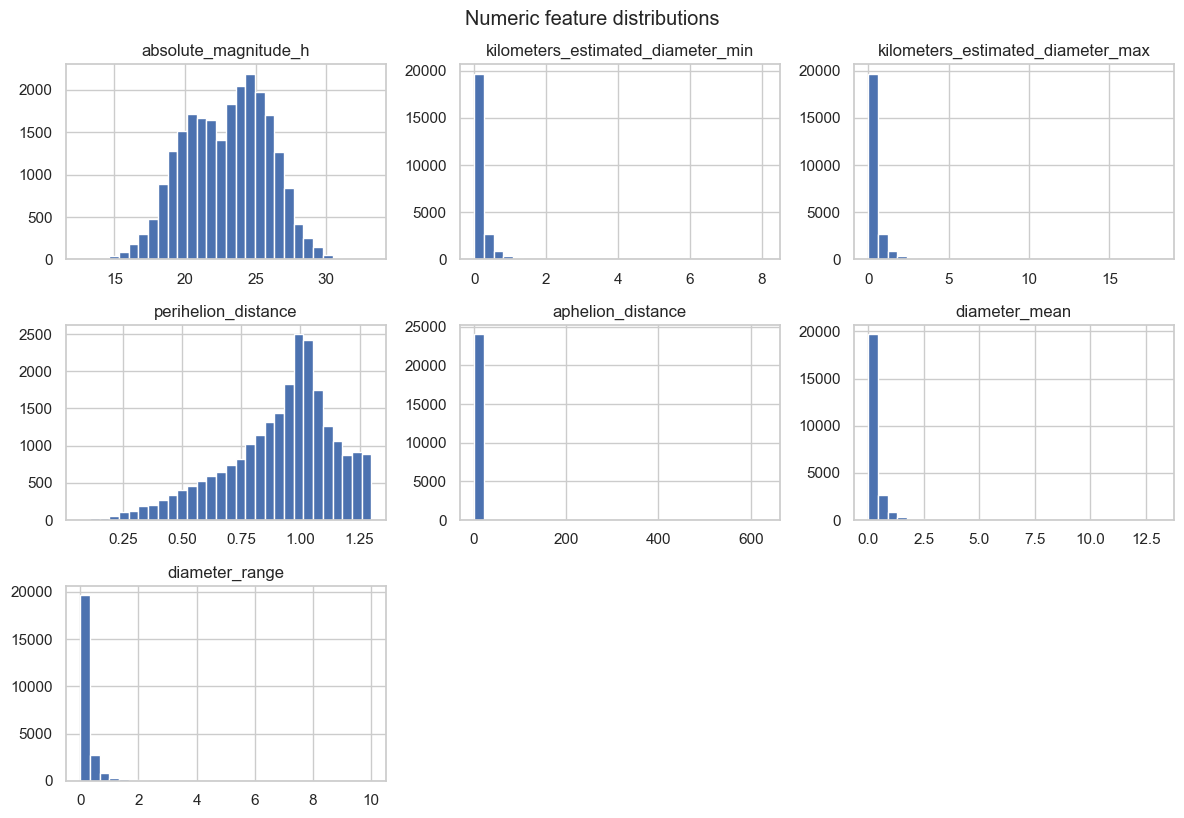

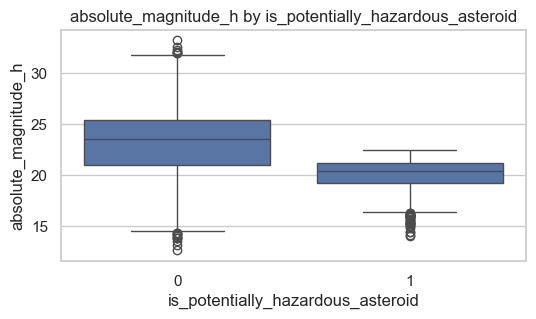

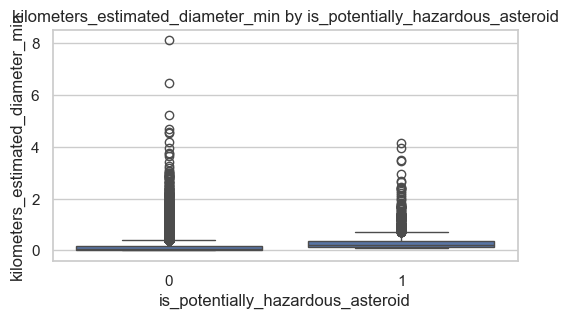

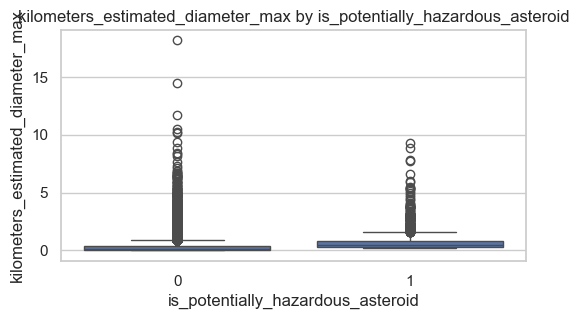

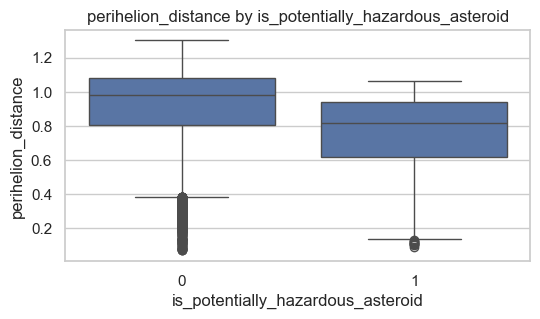

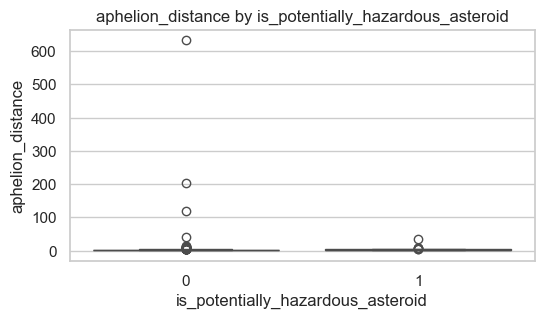

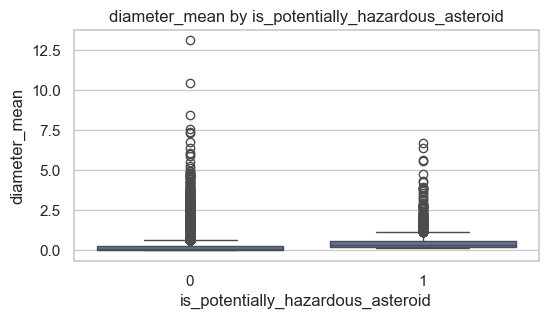

In [9]:
# Cell 8 — Visual EDA: distributions and target relationships
# Histogram of numeric features
plt.figure(figsize=(12, 8))
df[numeric_cols].hist(bins=30, layout=(int(np.ceil(len(numeric_cols)/3)),3), figsize=(12,8));
plt.tight_layout()
plt.suptitle("Numeric feature distributions", y=1.02)
plt.show()

# Boxplots of top numeric features vs target
top_plot_cols = numeric_cols[:6]  # adjust as needed
for col in top_plot_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"{col} by {target_col}")
    plt.show()


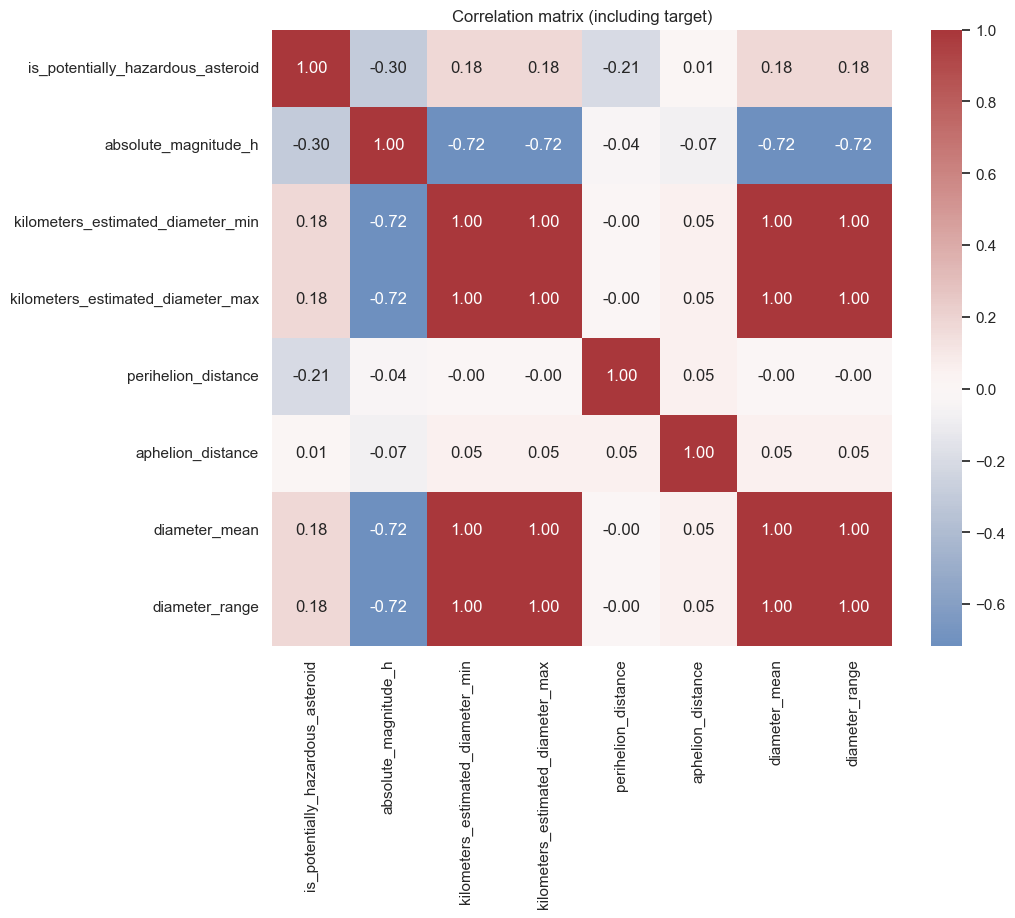

Correlation with target (abs sorted):
 absolute_magnitude_h                -0.298137
perihelion_distance                 -0.206415
diameter_range                       0.175040
kilometers_estimated_diameter_max    0.175040
diameter_mean                        0.175040
kilometers_estimated_diameter_min    0.175040
aphelion_distance                    0.009947
Name: is_potentially_hazardous_asteroid, dtype: float64


In [10]:
# Cell 9 — Correlation heatmap (numeric features)
plt.figure(figsize=(10,8))
corr = df[[target_col] + numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix (including target)")
plt.show()

# Print correlation with target sorted
corr_with_target = corr[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
print("Correlation with target (abs sorted):\n", corr_with_target)


In [11]:
# Cell 10 — Simple feature selection: SelectKBest (univariate ANOVA)
# We'll impute missing numeric values and run SelectKBest to see which numeric features associate with target.
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='median')
X_num = pd.DataFrame(num_imputer.fit_transform(df[numeric_cols]), columns=numeric_cols)
y = df[target_col].values

selector = SelectKBest(score_func=f_classif, k=min(8, X_num.shape[1]))
selector.fit(X_num, y)
scores = pd.Series(selector.scores_, index=numeric_cols).sort_values(ascending=False)
print("SelectKBest F-scores:\n", scores)


SelectKBest F-scores:
 absolute_magnitude_h                 2341.243601
perihelion_distance                  1067.990890
diameter_range                        757.971218
kilometers_estimated_diameter_max     757.971218
diameter_mean                         757.971218
kilometers_estimated_diameter_min     757.971218
aphelion_distance                       2.374760
dtype: float64


In [12]:
# Cell 11 — Final feature list decision
# Use:
# - numeric features: keep top ones from SelectKBest or domain ones (diameter_mean, absolute_magnitude_h, perihelion_distance, aphelion_distance, diameter_range, obs_span_days if present)
# - categorical: orbit_class (one-hot)
top_numeric = scores.index.tolist()[:8]  # adjust number if you like
print("Top numeric features chosen:", top_numeric)

final_numeric = [c for c in top_numeric if c in numeric_cols]
final_categorical = [c for c in categorical_cols]  # e.g., ['orbit_class'] if present
print("Final numeric:", final_numeric, "Final categorical:", final_categorical)


Top numeric features chosen: ['absolute_magnitude_h', 'perihelion_distance', 'diameter_range', 'kilometers_estimated_diameter_max', 'diameter_mean', 'kilometers_estimated_diameter_min', 'aphelion_distance']
Final numeric: ['absolute_magnitude_h', 'perihelion_distance', 'diameter_range', 'kilometers_estimated_diameter_max', 'diameter_mean', 'kilometers_estimated_diameter_min', 'aphelion_distance'] Final categorical: []


In [13]:
# Cell 12 — Build preprocessing pipeline
# Numeric: impute -> scale
# Categorical: impute -> onehot
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, final_numeric),
        ('cat', categorical_transformer, final_categorical)
    ],
    remainder='drop'  # drop other columns
)

# Quick test transform to see resulting feature dimension
X_pre = preprocessor.fit_transform(df)
print("Preprocessed feature matrix shape:", X_pre.shape)


Preprocessed feature matrix shape: (24000, 7)


In [14]:
# Cell 13 — Train / test split (stratified), and function for training & evaluation
X = df[final_numeric + final_categorical]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train/test shapes:", X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts())

# Function to train pipeline and evaluate
def train_and_evaluate(model, model_name="model"):
    # make a full pipeline that includes preprocessor and model
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = None
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        # try decision_function then scale to 0-1
        try:
            df_scores = pipe.decision_function(X_test)
            # normalize
            from sklearn.preprocessing import MinMaxScaler
            y_proba = MinMaxScaler().fit_transform(df_scores.reshape(-1,1)).ravel()
        except Exception:
            y_proba = None

    # metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(f"--- {model_name} ---")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    if roc is not None:
        print("ROC AUC:", roc)
    print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC curve
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure()
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc:.3f})")
        plt.plot([0,1], [0,1], '--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} ROC Curve")
        plt.legend()
        plt.show()

    return pipe


Train/test shapes: (19200, 7) (4800, 7) is_potentially_hazardous_asteroid
0    17525
1     1675
Name: count, dtype: int64 is_potentially_hazardous_asteroid
0    4381
1     419
Name: count, dtype: int64


--- Logistic Regression ---
Accuracy: 0.90625
Precision: 0.28169014084507044
Recall: 0.0477326968973747
F1: 0.08163265306122448
ROC AUC: 0.875747900322449

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95      4381
           1       0.28      0.05      0.08       419

    accuracy                           0.91      4800
   macro avg       0.60      0.52      0.52      4800
weighted avg       0.86      0.91      0.87      4800



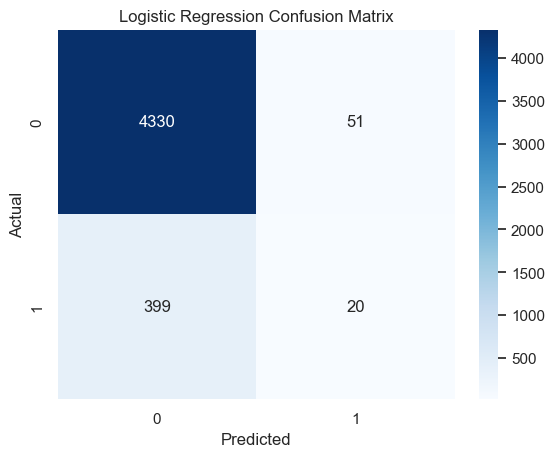

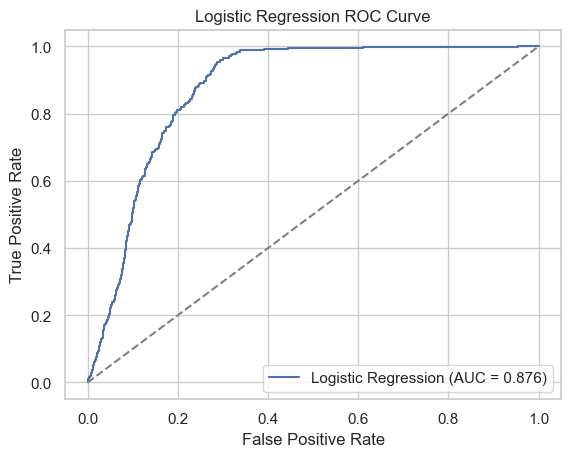

In [15]:
# Cell 14 — Train Logistic Regression
log_pipe = train_and_evaluate(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), "Logistic Regression")


--- Random Forest ---
Accuracy: 0.909375
Precision: 0.47333333333333333
Recall: 0.33890214797136037
F1: 0.3949930458970793
ROC AUC: 0.9346132327761614

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      4381
           1       0.47      0.34      0.39       419

    accuracy                           0.91      4800
   macro avg       0.71      0.65      0.67      4800
weighted avg       0.90      0.91      0.90      4800



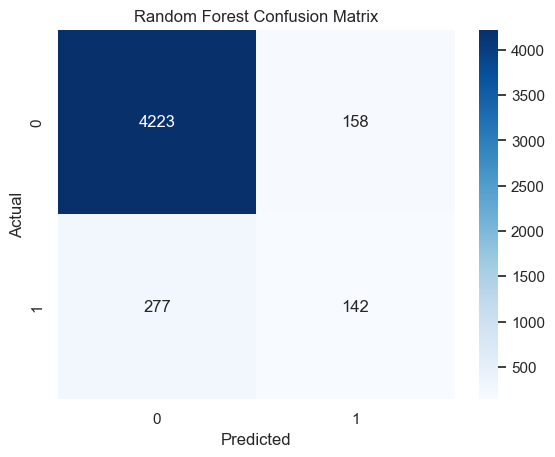

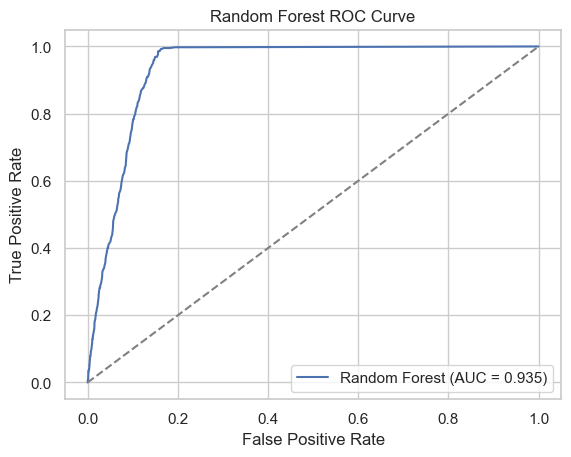

In [16]:
# Cell 15 — Train Random Forest
rf_pipe = train_and_evaluate(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), "Random Forest")


--- Gradient Boosting ---
Accuracy: 0.9135416666666667
Precision: 0.5126582278481012
Recall: 0.19331742243436753
F1: 0.2807625649913345
ROC AUC: 0.9405953458169062

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95      4381
           1       0.51      0.19      0.28       419

    accuracy                           0.91      4800
   macro avg       0.72      0.59      0.62      4800
weighted avg       0.89      0.91      0.90      4800



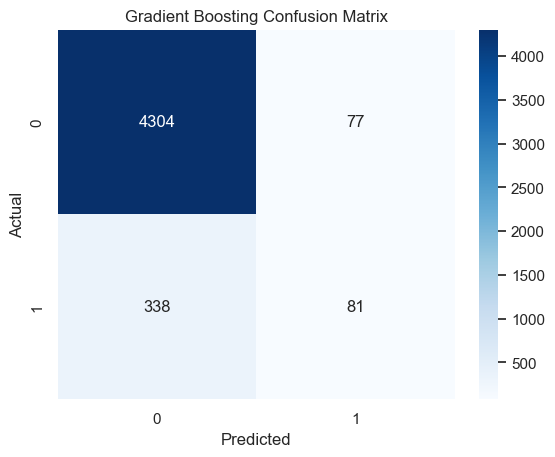

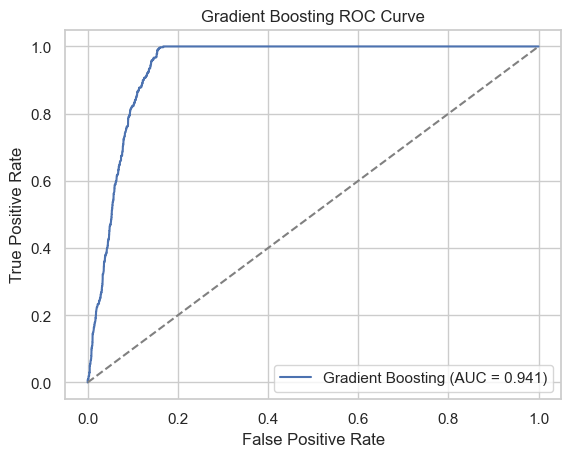

In [17]:
# Cell 16 — Train Gradient Boosting (optional)
gb_pipe = train_and_evaluate(GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE), "Gradient Boosting")


In [18]:
# Cell 17 — Cross-validation estimate for best model(s)
# Use StratifiedKFold cross validation on the pipeline and report mean accuracy
from sklearn.model_selection import cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in [("Logistic", log_pipe), ("RF", rf_pipe), ("GB", gb_pipe)]:
    # cross_val_score needs original X, y and the pipeline (reconstructed to avoid fitted transforms)
    if name == "Logistic":
        model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    elif name == "RF":
        model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    else:
        model = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)

    full_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_val_score(full_pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"{name} CV accuracy: mean={scores.mean():.4f}, std={scores.std():.4f}, scores={scores}")


Logistic CV accuracy: mean=0.9053, std=0.0012, scores=[0.90520833 0.906875   0.904375   0.90625    0.90375   ]
RF CV accuracy: mean=0.9063, std=0.0025, scores=[0.91041667 0.9075     0.904375   0.903125   0.90625   ]
GB CV accuracy: mean=0.9132, std=0.0013, scores=[0.91354167 0.91125    0.914375   0.91208333 0.91479167]


Feature names used: ['absolute_magnitude_h', 'perihelion_distance', 'diameter_range', 'kilometers_estimated_diameter_max', 'diameter_mean', 'kilometers_estimated_diameter_min', 'aphelion_distance']


,feature,importance
1,perihelion_distance,0.391047
6,aphelion_distance,0.230212
0,absolute_magnitude_h,0.093120
5,kilometers_estimated_diameter_min,0.081803
2,diameter_range,0.071042
4,diameter_mean,0.070470
3,kilometers_estimated_diameter_max,0.062306


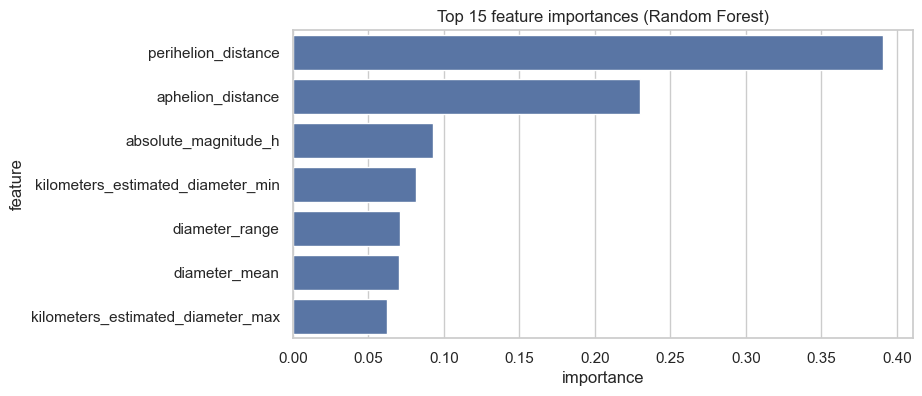

In [19]:
# Cell 18 — Feature importance (for tree-based model)
# Extract feature names after preprocessing to map importances
def get_feature_names(preprocessor):
    # numeric feature names
    num_names = final_numeric
    # onehot feature names
    cat_names = []
    if final_categorical:
        # get categories from fitted onehot encoder inside the pipeline
        # We can fit the preprocessor on the whole dataset X to get feature names
        preprocessor.fit(X)
        ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
        ohe_feature_names = ohe.get_feature_names_out(final_categorical)
        cat_names = list(ohe_feature_names)
    return num_names + cat_names

feat_names = get_feature_names(preprocessor)
print("Feature names used:", feat_names)

# For Random Forest trained earlier (rf_pipe), get feature importances
rf_model = rf_pipe.named_steps['classifier']
try:
    importances = rf_model.feature_importances_
    feat_imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)
    display(feat_imp_df.head(15))
    # plot
    plt.figure(figsize=(8,4))
    sns.barplot(data=feat_imp_df.head(15), x='importance', y='feature')
    plt.title("Top 15 feature importances (Random Forest)")
    plt.show()
except Exception as e:
    print("Could not extract feature importances:", e)